# Calculation general CME distributions for a fast rotation star. 

## the interesting quantity now is the dopplershift in the direction of the observer

The velocity component of the CME in direction of the observer, 
$$ v \cos \beta = v (\cos \theta \cos \theta' + \sin \theta\sin \theta' \cos \phi') $$
will now be supplemented by a component comming from the rotation of the star itself, namely 
$$\omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta,$$
where $\omega (\alpha)$ is the angular frequency at lattitude $\alpha$ and $R$ is the radius of the star, which we assume to be constant. 
For a rigid rotator $\omega (\alpha) = \omega$, for the solar case this has been observed to obey some relation of the form $\omega (\alpha) = A + B \sin^2 + C \sin^4$. The assumption that the fast rotator is a perfect sphere can be corrected by taking $R(\alpha)$ insteand where the radius can vary with lattitude. 

In order for this correction to be significant, the order of magnitude of $\omega R$ should be on the order of the velocity of a CME $v$. In the solar case, this correction will be neglegtible. 

To solve for the distribution in dopplershift $d$ in direction of the observer, we solve following integral
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta ).
\end{equation}

import dependencies

In [1]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad


Define the 3D distribution as a function of lattitude $\alpha$.
(obtained in experimental_flare_distribution.ipynb)

In [2]:
# general distribution of active regions per unit area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)
Rn = 1
def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err) / Rn
            # fit of dist when integrated over phi and absolute value so accounting for that

Rn = quad(lambda x : rho(x) * np.sin(x) , 0, np.pi)[0]

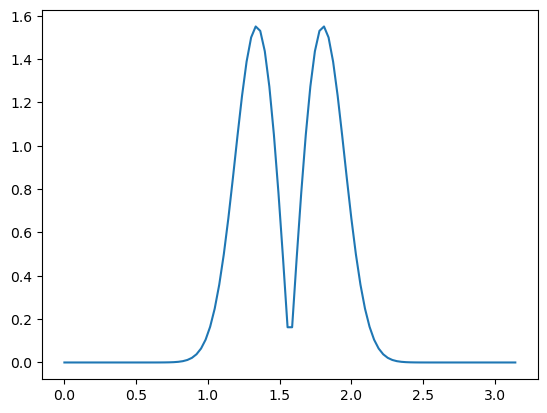

In [3]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))

Before for flare distribution we had the relation
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$

Now we work with different variables but they are similar as follows $\beta \sim \alpha, \theta \sim \tau, \theta'\sim \theta$ and $ \phi'\sim \phi$ so  
$$
\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta  $$
For a proper description we refer to the associated paper.



The distribution for CME angle is assumed to be gaussion around 0 in the angle with the zenit. We here under properly normalize the distribution!

0.4946944833802725
1.0


Text(0, 0.5, "distribution of CMEs at angle $\\theta'$ with the zenit")

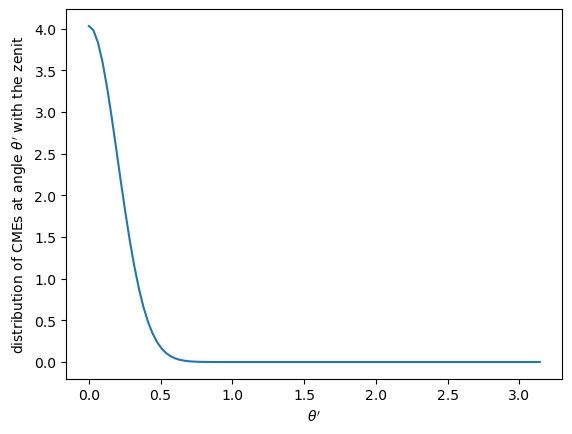

In [4]:
from scipy.stats import norm
# normalization, later to be determined
N = 1

def rho_CME(theta2, loc=0, scale = 0.2):
    return norm.pdf(theta2, loc, scale) /N

f = lambda theta2 : rho_CME(theta2) * np.sin(theta2) * 2 * np.pi


N = quad(f, 0, np.pi/2)[0]
print(N)
print(quad(f, 0, np.pi/2)[0])

T = np.linspace(0, np.pi, 100)
plt.plot(T, rho_CME(T))
plt.xlabel("$\\theta'$")
plt.ylabel("distribution of CMEs at angle $\\theta'$ with the zenit")



# Calculation of distribution of CMEs in viewing angle $\beta$ for given $\tau$.

Now we calculate the distribution in viewing angle $\beta$ for a given orientation angle $\tau$. 
This is a numerically exhausting procedure. 
We have a fast (monte carlo) and a slow approach (scipy.integrate.nquad) however it in both options struggles to get sufficient datapoints with good accuracy.

Later we will calculate the distribution of CMEs in viewing angle $\beta$ for average $\tau$ which can be analytically simplified and quickly solved.

If all integrations can be done at once this will save much time!
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta ).
\end{equation}

so we use $d = v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) + \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta$, or equivalently that
$\cos \phi' = \frac{d- v\cos\theta'\cos\theta - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta}{v\sin \theta'\sin\theta}$
to find that (this step was flagged as unverified previously; confirmed correct against a brute-force simulation that samples the 3D geometry directly, independent of this delta-function algebra -- see EK_Draconis_CME_observation_ratio.ipynb):

\begin{equation}
    \int d\phi'   \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta) = \frac{1}{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',d)}
\end{equation}
since $\int dx \delta(f(x)) = \int dy (f'(x))^{-1} \delta(y) = 1/f'(x_0)$ where $y=f(x)$ and  $x_0$ such that $y=f(x_0)=0$.

Therefore 

\begin{equation}
    \rho_d(d) = \frac{1}{N} \int \sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi))  \sin\theta' d\theta'  \rho^{CME}(\theta') \frac{1}{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',d)}.
\end{equation}
Hence, 
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int  d\theta d\phi  d\theta'  \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta') \frac{1}{\sin\phi'(\theta, \theta',d)}.
\end{equation}


# intergral numerical

## rigid rotator satisfying 
$$\omega R = v$$

In [5]:
import time
from scipy.stats import qmc

omega = 1
v = 1
R = 1

def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))


def mc_rho_dops(dops, tau, m=23, seed=0):
    """Vectorised, scrambled-Sobol' Monte Carlo estimate of rho_dop(dop, tau) for every dop at once.
    Replaces the nquad-based get_rho_dop/rho_dops below: with the corrected 1/sin(phi') integrand
    (sin(theta)*sin(theta2) cancelled against the measure, see the markdown above), nquad becomes
    impractically slow (a genuine, if integrable, singularity at the domain boundary), the same issue
    as in CME_distribution.ipynb. m=23 means 2**23 (~8.4M) samples.
    """
    sampler = qmc.Sobol(d=3, scramble=True, seed=seed)
    u = sampler.random_base2(m=m)
    theta = (u[:, 0] * np.pi)[:, None]
    phi = (u[:, 1] * 2 * np.pi)[:, None]
    theta2 = (u[:, 2] * np.pi / 2)[:, None]
    dops_ = np.asarray(dops)[None, :]

    alpha = get_alpha(tau, theta, phi)
    denom = v * np.sin(theta) * np.sin(theta2)
    cosphi2 = (dops_ - v * np.cos(theta) * np.cos(theta2)
               - omega * R * np.sin(tau) * np.sin(phi) * np.sin(theta)) / denom
    valid = np.abs(cosphi2) <= 1
    sinphi2 = np.where(valid, np.sqrt(np.clip(1 - cosphi2**2, 0, None)), 0.0)

    # corrected: sin(theta)*sin(theta2) cancelled against the measure (was left in previously).
    integrand = np.where(valid, rho(alpha) * rho_CME(theta2) / (sinphi2 + 1e-3), 0.0)
    volume = np.pi * (2 * np.pi) * (np.pi / 2)
    return integrand.mean(axis=0) * volume


def rho_dops(dops, tau):
    return mc_rho_dops(dops, tau)

dops = np.linspace(-2,2, 20)
Taus =  np.linspace(0,np.pi/2, 5)

x = np.linspace(0,np.pi, 300)


def run_taus(T):
    dens = []
    for tau in T:
        print(f"calculating tau = {tau}")
        dens.append(rho_dops(dops, tau))

    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs")
    plt.xticks(np.linspace(0,np.pi, 4), range(0,181,60))
    plt.xlabel(r"incoming velocity in units of  [$v$]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi)
    plt.show()
    return np.array(dens)


In [6]:
from pathlib import Path

def get_or_create_data(name):
    filename = f'calculations/{name}_rotation.npy'
    file_path = Path(filename)

    
    if file_path.exists():
        print(f"File '{filename}' found.")
        data = np.load(filename)
    else:
        print(f"File '{filename}' not found. Creating new data...")


        # --- FIX STARTS HERE ---
        # Create the 'calculations' directory if it doesn't exist
        # parents=True: creates any missing parent folders
        # exist_ok=True: doesn't crash if the folder already exists
        file_path.parent.mkdir(parents=True, exist_ok=True)
        # -----------------------

        # Replace this with your actual data generation logic
        data = run_taus(Taus)
        
        # Save the file so it exists next time
        np.save(filename, data)
        print(f"Data saved to '{filename}'.")
        
    return data

dens = get_or_create_data("sundist")


File 'calculations/sundist_rotation.npy' found.


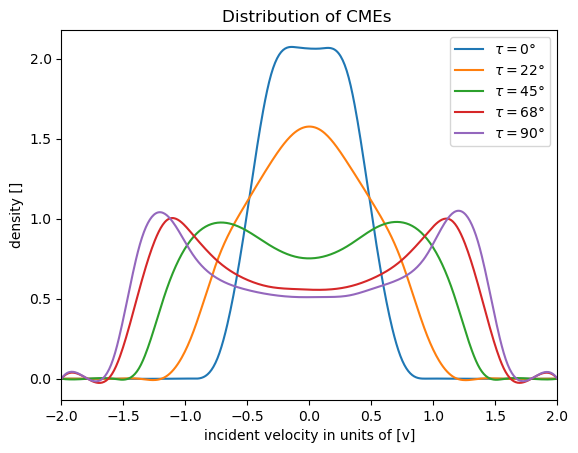

In [7]:

x = np.linspace(-2,2, 500)

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(dops, d/(np.average(d) * 2))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    # plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xlabel(r"incident velocity in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(-2,2)
    # plt.ylim(0,1)
    plt.show()


plotting_(dens, Taus)



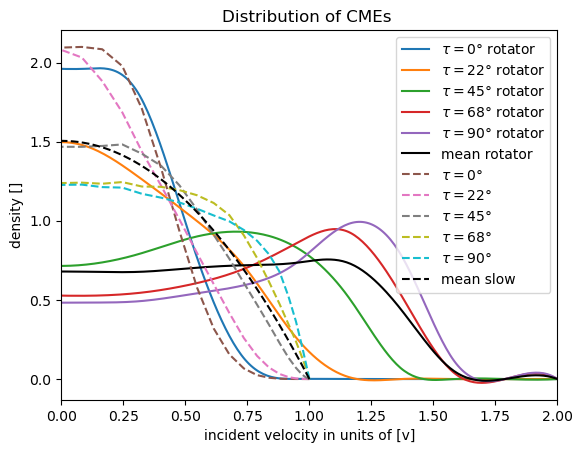

In [8]:
dens_nonrot = np.load('calculations/sundist.npy')

betas = np.linspace(0,np.pi/2, 20)
Taus =  np.linspace(0,np.pi/2, 5)


x = np.linspace(-2,2, 500)

from scipy.interpolate import make_interp_spline


def plotting_compare(dens, dens_nonrot, taus):
    mean_rot= np.zeros(500)
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(dops, d/(np.average(d) * 2))(x)
        normalisatie = np.sum((smooth_curve[:-1] + smooth_curve[1:])/2 * (x[1:] - x[:-1])) / 2
        plt.plot(x, smooth_curve / normalisatie, label=fr"$\tau=${round(taus[i]/np.pi*180)}° rotator")
        mean_rot += smooth_curve / normalisatie * np.sin(taus[i])
    plt.plot(x, mean_rot / np.sum(np.sin(taus)),  "-", color='black', label="mean rotator")
       
    for i,d in enumerate(dens_nonrot):
        # ind = np.argsort(np.cos(betas))
        # x2 = np.cos(betas)[ind]
        # d2 = (np.sin(betas) * d  / (np.average(d) * np.pi) )[ind]
        # smooth_curve = make_interp_spline(x2, d2)(x)
        # plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
        plt.plot(np.cos(betas), 2* np.sin(betas) * d / (np.average(d * np.sin(betas)**2) * np.pi), '--', label=fr"$\tau=${round(taus[i]/np.pi*180)}° ")
    y = np.linspace(0,np.pi, 300)
    plt.plot(np.cos(y), 2*np.sin(y)**2 / (np.average(np.sin(y) * np.sin(y)**2) * np.pi), "--", color='black', label="mean slow ")
    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xlabel(r"incident velocity in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(0,2)
    # plt.ylim(0,1)
    plt.show()


plotting_compare(dens, dens_nonrot, Taus)



# Combined figure: slow vs. fast rotator, solar-like activity, PDF/CDF vs. incident velocity

Same paper-style 2x2 layout as the combined figure in `CME_distribution.ipynb`, but with $\beta$
replaced by the incident (line-of-sight) velocity $d/v_0$ directly, and rows now distinguishing the
rotation speed instead of the flare-source distribution: **slow rotator** ($\omega R=0$, the
non-rotating limit — physically equivalent to the top row of the beta-based figure, but computed
directly in the $d$-domain with the same corrected estimator rather than reparametrising the
beta-domain result, to avoid any risk of a Jacobian-transform mistake) vs. **fast rotator**
($\omega R=v_0$, this notebook's existing toy-case convention, see the markdown above). Both use the
corrected `1/sin(phi')` d-domain formula (no leftover $\sin\theta\sin\theta'$ factor) from
`mc_rho_dops` above — parametrised here by `rho(alpha)` and $\omega R$ instead of relying on this
notebook's module-level `rho`/`omega`/`v`/`R`, so it can't accidentally mutate state used elsewhere
in this notebook.

solar tau 0 done
solar tau 1 done
solar tau 2 done
solar tau 3 done
solar tau 4 done


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_14064\944243426.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_slow = np.array([d / np.trapz(d, dops_grid) for d in dens_slow_solar])
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_14064\944243426.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_fast = np.array([d / np.trapz(d, dops_grid) for d in dens_fast_solar])


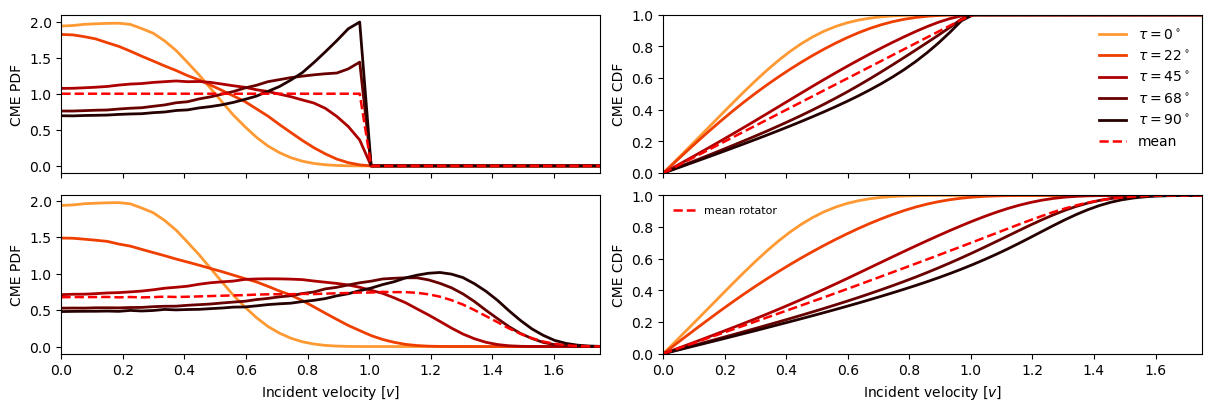

In [9]:
from pathlib import Path

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(exist_ok=True)


def rho_solar_rot(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit) / (np.sin(alpha) + err)


def mc_rho_dops_param(dops, tau, rho_fn, omega_R, v0=1.0, m=23, seed=0):
    """Same corrected, Sobol'-sampled d-domain estimator as mc_rho_dops above, parametrised by
    rho(alpha) and omega*R so different scenarios/rotation speeds can be evaluated without
    mutating the module-level rho/omega/v/R used elsewhere in this notebook."""
    sampler = qmc.Sobol(d=3, scramble=True, seed=seed)
    u = sampler.random_base2(m=m)
    theta = (u[:, 0] * np.pi)[:, None]
    phi = (u[:, 1] * 2 * np.pi)[:, None]
    theta2 = (u[:, 2] * np.pi / 2)[:, None]
    dops_ = np.asarray(dops)[None, :]

    alpha = get_alpha(tau, theta, phi)
    denom = v0 * np.sin(theta) * np.sin(theta2)
    cosphi2 = (dops_ - v0 * np.cos(theta) * np.cos(theta2)
               - omega_R * np.sin(tau) * np.sin(phi) * np.sin(theta)) / denom
    valid = np.abs(cosphi2) <= 1
    sinphi2 = np.where(valid, np.sqrt(np.clip(1 - cosphi2**2, 0, None)), 0.0)

    integrand = np.where(valid, rho_fn(alpha) * rho_CME(theta2) / (sinphi2 + 1e-3), 0.0)
    volume = np.pi * (2 * np.pi) * (np.pi / 2)
    return integrand.mean(axis=0) * volume


def cache_npy(name, compute_fn):
    filename = f"calculations/{name}.npy"
    file_path = Path(filename)
    if file_path.exists():
        return np.load(filename)
    file_path.parent.mkdir(parents=True, exist_ok=True)
    data = compute_fn()
    np.save(filename, data)
    return data


def cdf_from_pdf(x, pdf):
    dx = np.diff(x)
    mid = 0.5 * (pdf[1:] + pdf[:-1])
    cdf = np.concatenate([[0.0], np.cumsum(mid * dx)])
    return cdf / cdf[-1] if cdf[-1] != 0 else cdf


dops_grid = np.linspace(0, 2.2, 60)

dens_slow_solar, dens_fast_solar = [], []
for i, tau in enumerate(Taus):
    dens_slow_solar.append(cache_npy(f"solar_rotation_slow_tau{i}",
                                      lambda tau=tau: mc_rho_dops_param(dops_grid, tau, rho_solar_rot, omega_R=0.0)))
    dens_fast_solar.append(cache_npy(f"solar_rotation_fast_tau{i}",
                                      lambda tau=tau: mc_rho_dops_param(dops_grid, tau, rho_solar_rot, omega_R=1.0)))
    print(f"solar tau {i} done")
dens_slow_solar = np.array(dens_slow_solar)
dens_fast_solar = np.array(dens_fast_solar)

pdf_slow = np.array([d / np.trapz(d, dops_grid) for d in dens_slow_solar])
pdf_fast = np.array([d / np.trapz(d, dops_grid) for d in dens_fast_solar])
cdf_slow = np.array([cdf_from_pdf(dops_grid, p) for p in pdf_slow])
cdf_fast = np.array([cdf_from_pdf(dops_grid, p) for p in pdf_fast])

v0 = 1.0
# slow-rotator row: no rotation, so d can never exceed v0 -- the "mean" reference is the usual
# flat/step-function isotropic curve (uniform in d over [0, v0]) and its linear CDF.
pdf_mean_ref = np.where(dops_grid <= v0, 1.0 / v0, 0.0)
cdf_mean_ref = np.clip(dops_grid / v0, 0, 1)

# fast-rotator row: rotation lets d exceed v0, so that flat/step reference no longer applies.
# Instead use the sin(tau)-weighted average of the actual computed curves -- the physically
# meaningful "mean over a randomly oriented rotation axis" (tau is distributed proportional to
# sin(tau) for an isotropic axis direction), matching this notebook's original "mean rotator".
pdf_mean_fast = np.average(pdf_fast, axis=0, weights=np.sin(Taus))
cdf_mean_fast = cdf_from_pdf(dops_grid, pdf_mean_fast)

cmap = plt.get_cmap("gist_heat_r")
colors = [cmap(c) for c in np.linspace(0.2, 0.9, len(Taus))]

fig, axes = plt.subplots(2, 2, figsize=(12, 4), sharex=True, constrained_layout=True)
for i, tau in enumerate(Taus):
    col = colors[i]
    lab = fr"$\tau={int(round(tau*180/np.pi))}^\circ$"
    axes[0, 0].plot(dops_grid, pdf_slow[i], lw=2, color=col)
    axes[0, 1].plot(dops_grid, cdf_slow[i], lw=2, color=col, label=lab)
    axes[1, 0].plot(dops_grid, pdf_fast[i], lw=2, color=col)
    axes[1, 1].plot(dops_grid, cdf_fast[i], lw=2, color=col)

axes[0, 0].plot(dops_grid, pdf_mean_ref, "--", color="red", lw=1.8)
axes[1, 0].plot(dops_grid, pdf_mean_fast, "--", color="red", lw=1.8)
axes[0, 1].plot(dops_grid, cdf_mean_ref, "--", color="red", lw=1.8, label="mean")
axes[1, 1].plot(dops_grid, cdf_mean_fast, "--", color="red", lw=1.8, label="mean rotator")

axes[0, 0].set_ylabel("CME PDF")
axes[1, 0].set_ylabel("CME PDF")
axes[0, 1].set_ylabel("CME CDF")
axes[1, 1].set_ylabel("CME CDF")
axes[1, 0].set_xlabel("Incident velocity [$v$]")
axes[1, 1].set_xlabel("Incident velocity [$v$]")

for ax in axes[:, 1]:
    ax.set_ylim(0, 1)
for ax in axes.ravel():
    ax.set_xlim(0, 1.75)

axes[0, 1].legend(frameon=False)
axes[1, 1].legend(frameon=False, fontsize=8)

plt.savefig(FIGURES_DIR / "CME_dist_rotation_solar_slow_vs_fast.pdf")
plt.show()


# Polar flares

0.5000000000000001


Text(0, 0.5, 'probability density per unit area')

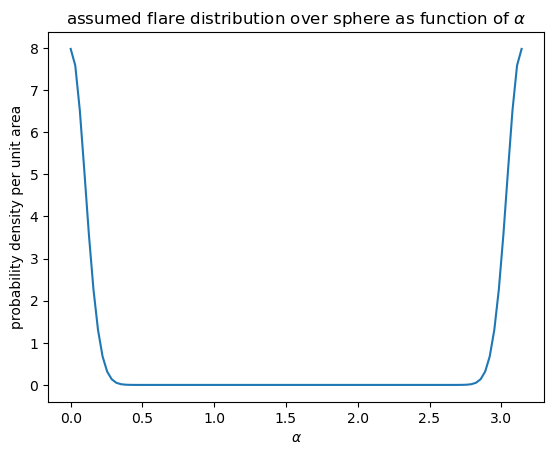

In [10]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return (norm.pdf(alpha, loc, scale) + norm.pdf(alpha, loc+np.pi, scale)) /N

N = quad(lambda a :  rho(a), 0, np.pi/2)[0]
print(N)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [11]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

    
def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()


0.0 (0.9993158136231646, 3.647190528409362e-12)


0.39269908169872414 (0.9993158136231631, 1.694194277505706e-13)


0.7853981633974483 (0.9993158136231668, 7.908570194260995e-11)


1.1780972450961724 (0.9993158136231668, 4.542747928977166e-09)


1.5707963267948966 (0.9993158136231646, 1.2719183056504428e-09)


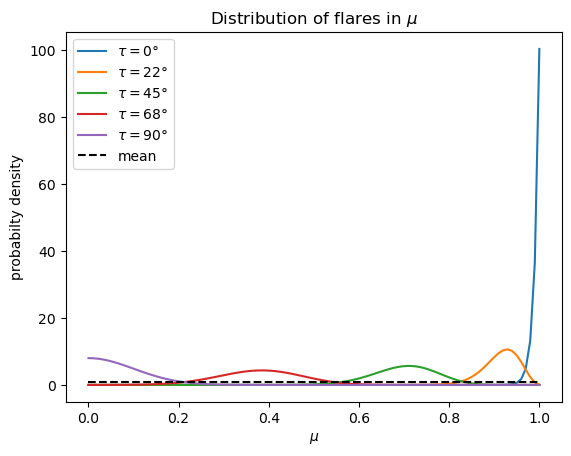

File 'calculations/polardist_rotation.npy' found.


In [12]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dops = np.linspace(0,1.3, 40)
dens = get_or_create_data("polardist")


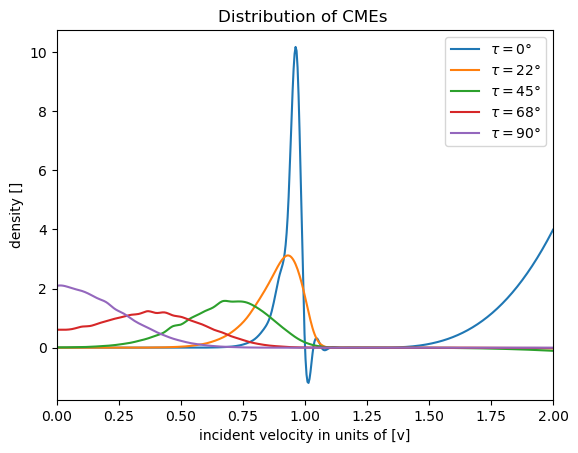

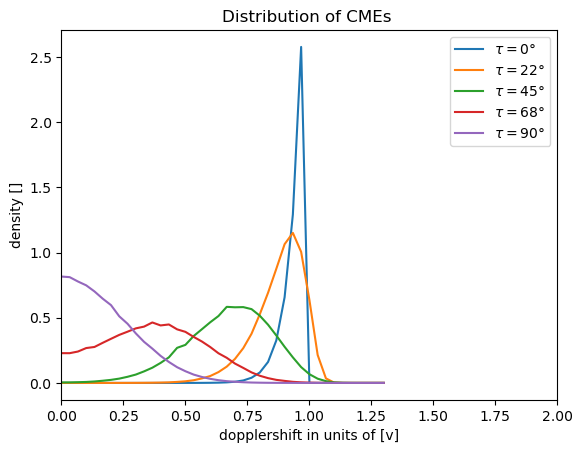

In [13]:

def plotting_2(dens, taus):
    for i,d in enumerate(dens):
        # smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(dops, d, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    # plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    # plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    # ax = plt.gca()
    # secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    # secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel("dopplershift in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(0, 2)
    # plt.ylim(0,1)
    plt.show()


x = np.linspace(0,2, 500)



def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(dops, d/(np.average(d) * 2))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    # plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xlabel(r"incident velocity in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(0,2)
    # plt.ylim(0,1)
    plt.show()


plotting_(dens, Taus)
plotting_2(dens, Taus)


# conclusion: don't smooth things as they are too singular around 1


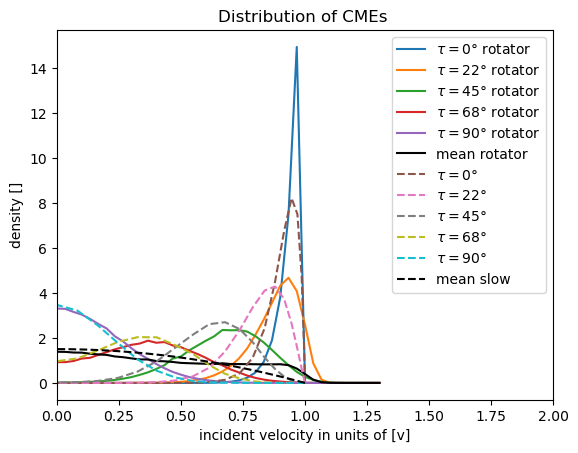

In [14]:
dens_nonrot = np.load('calculations/polardist.npy')

betas = np.linspace(0,np.pi/2, 20)
Taus =  np.linspace(0,np.pi/2, 5)


x = np.linspace(-2,2, 500)

from scipy.interpolate import make_interp_spline


# def plotting_compare(dens, dens_nonrot, taus):
#     for i,d in enumerate(dens):
#         normalisatie = np.sum((d[:-1] + d[1:])/2 * (dops[1:] - dops[:-1])) 
#         plt.plot(dops, d / normalisatie, label=fr"$\tau=${round(taus[i]/np.pi*180)}° rotator")
       
#     for i,d in enumerate(dens_nonrot):
#         # ind = np.argsort(np.cos(betas))
#         # x2 = np.cos(betas)[ind]
#         # d2 = (np.sin(betas) * d  / (np.average(d) * np.pi) )[ind]
#         # smooth_curve = make_interp_spline(x2, d2)(x)
#         # plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
#         plt.plot(np.cos(betas), 2* np.sin(betas) * d / (np.average(d * np.sin(betas)**2) * np.pi), '--', label=fr"$\tau=${round(taus[i]/np.pi*180)}° ")
#     plt.legend()
#     plt.title("Distribution of CMEs ")
#     plt.xlabel(r"incident velocity in units of [v]")
#     plt.ylabel(r"density []")
#     plt.xlim(0,2)
#     # plt.ylim(0,1)
#     plt.show()


def plotting_compare(dens, dens_nonrot, taus):
    mean_rot= np.zeros(40)
    for i,d in enumerate(dens):
        normalisatie = np.sum((d[:-1] + d[1:])/2 * (dops[1:] - dops[:-1])) 
        plt.plot(dops, d / normalisatie, label=fr"$\tau=${round(taus[i]/np.pi*180)}° rotator")
        mean_rot += d / normalisatie * np.sin(taus[i])
    plt.plot(dops, mean_rot / np.sum(np.sin(taus)),  "-", color='black', label="mean rotator")
       
    for i,d in enumerate(dens_nonrot):
        # ind = np.argsort(np.cos(betas))
        # x2 = np.cos(betas)[ind]
        # d2 = (np.sin(betas) * d  / (np.average(d) * np.pi) )[ind]
        # smooth_curve = make_interp_spline(x2, d2)(x)
        # plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
        plt.plot(np.cos(betas), 2* np.sin(betas) * d / (np.average(d * np.sin(betas)**2) * np.pi), '--', label=fr"$\tau=${round(taus[i]/np.pi*180)}° ")
    y = np.linspace(0,np.pi, 300)
    plt.plot(np.cos(y), 2*np.sin(y)**2 / (np.average(np.sin(y) * np.sin(y)**2) * np.pi), "--", color='black', label="mean slow ")
    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xlabel(r"incident velocity in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(0,2)
    # plt.ylim(0,1)
    plt.show()


plotting_compare(dens, dens_nonrot, Taus)

# Combined figure: slow vs. fast rotator, polar activity, PDF/CDF vs. incident velocity

Same as the combined solar-like figure above, but with the polar $\rho(\alpha)$ (activity
concentrated near both poles) from the "Polar flares" section instead.

polar tau 0 done
polar tau 1 done
polar tau 2 done
polar tau 3 done
polar tau 4 done


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_14064\2465811882.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_slow_p = np.array([d / np.trapz(d, dops_grid) for d in dens_slow_polar])
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_14064\2465811882.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_fast_p = np.array([d / np.trapz(d, dops_grid) for d in dens_fast_polar])


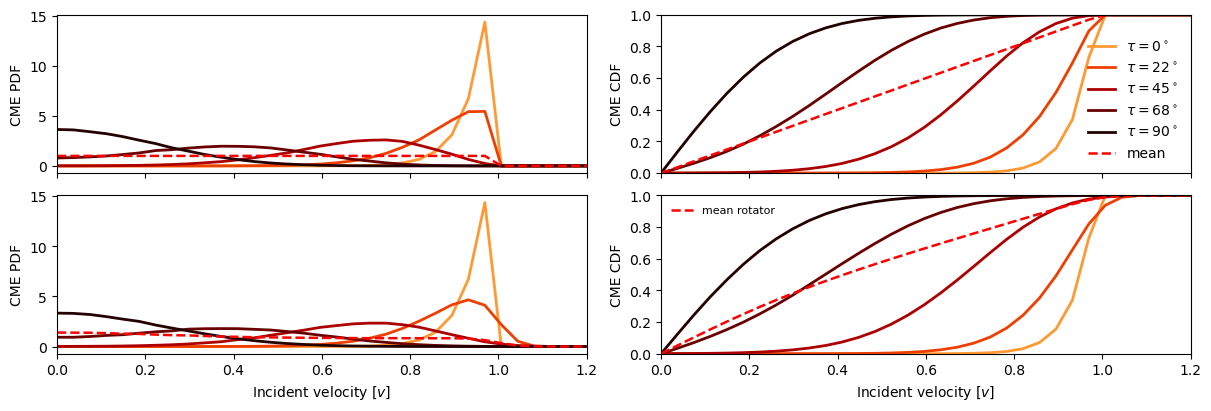

In [15]:
N_polar = quad(lambda a: norm.pdf(a, 0, 0.1) + norm.pdf(a, np.pi, 0.1), 0, np.pi / 2)[0]


def rho_polar_rot(alpha, loc=0, scale=0.1):
    return (norm.pdf(alpha, loc, scale) + norm.pdf(alpha, loc + np.pi, scale)) / N_polar


dens_slow_polar, dens_fast_polar = [], []
for i, tau in enumerate(Taus):
    dens_slow_polar.append(cache_npy(f"polar_rotation_slow_tau{i}",
                                      lambda tau=tau: mc_rho_dops_param(dops_grid, tau, rho_polar_rot, omega_R=0.0)))
    dens_fast_polar.append(cache_npy(f"polar_rotation_fast_tau{i}",
                                      lambda tau=tau: mc_rho_dops_param(dops_grid, tau, rho_polar_rot, omega_R=1.0)))
    print(f"polar tau {i} done")
dens_slow_polar = np.array(dens_slow_polar)
dens_fast_polar = np.array(dens_fast_polar)

pdf_slow_p = np.array([d / np.trapz(d, dops_grid) for d in dens_slow_polar])
pdf_fast_p = np.array([d / np.trapz(d, dops_grid) for d in dens_fast_polar])
cdf_slow_p = np.array([cdf_from_pdf(dops_grid, p) for p in pdf_slow_p])
cdf_fast_p = np.array([cdf_from_pdf(dops_grid, p) for p in pdf_fast_p])

# fast-rotator row: same sin(tau)-weighted "mean over random rotation-axis orientation" as the
# solar-like figure above, computed from the polar-activity curves instead.
pdf_mean_fast_p = np.average(pdf_fast_p, axis=0, weights=np.sin(Taus))
cdf_mean_fast_p = cdf_from_pdf(dops_grid, pdf_mean_fast_p)

fig, axes = plt.subplots(2, 2, figsize=(12, 4), sharex=True, constrained_layout=True)
for i, tau in enumerate(Taus):
    col = colors[i]
    lab = fr"$\tau={int(round(tau*180/np.pi))}^\circ$"
    axes[0, 0].plot(dops_grid, pdf_slow_p[i], lw=2, color=col)
    axes[0, 1].plot(dops_grid, cdf_slow_p[i], lw=2, color=col, label=lab)
    axes[1, 0].plot(dops_grid, pdf_fast_p[i], lw=2, color=col)
    axes[1, 1].plot(dops_grid, cdf_fast_p[i], lw=2, color=col)

axes[0, 0].plot(dops_grid, pdf_mean_ref, "--", color="red", lw=1.8)
axes[1, 0].plot(dops_grid, pdf_mean_fast_p, "--", color="red", lw=1.8)
axes[0, 1].plot(dops_grid, cdf_mean_ref, "--", color="red", lw=1.8, label="mean")
axes[1, 1].plot(dops_grid, cdf_mean_fast_p, "--", color="red", lw=1.8, label="mean rotator")

axes[0, 0].set_ylabel("CME PDF")
axes[1, 0].set_ylabel("CME PDF")
axes[0, 1].set_ylabel("CME CDF")
axes[1, 1].set_ylabel("CME CDF")
axes[1, 0].set_xlabel("Incident velocity [$v$]")
axes[1, 1].set_xlabel("Incident velocity [$v$]")

for ax in axes[:, 1]:
    ax.set_ylim(0, 1)
for ax in axes.ravel():
    ax.set_xlim(0, 1.2)

axes[0, 1].legend(frameon=False)
axes[1, 1].legend(frameon=False, fontsize=8)

plt.savefig(FIGURES_DIR / "CME_dist_rotation_polar_slow_vs_fast.pdf")
plt.show()


old with only 20 points:

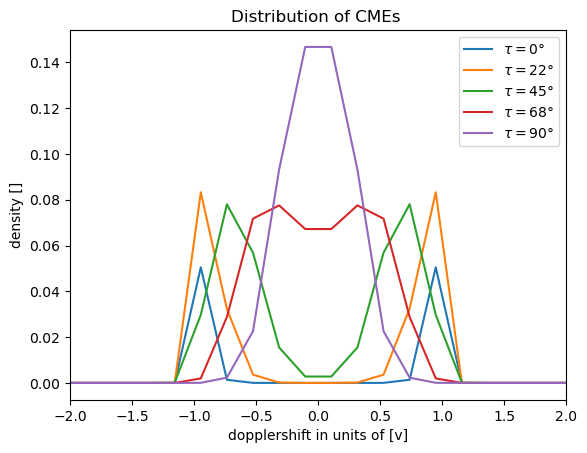
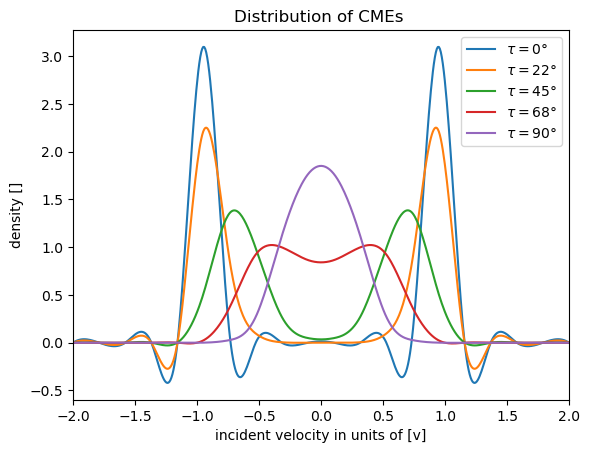

# Uniform distribution

0.9999999999999999


Text(0, 0.5, 'probability density per unit area')

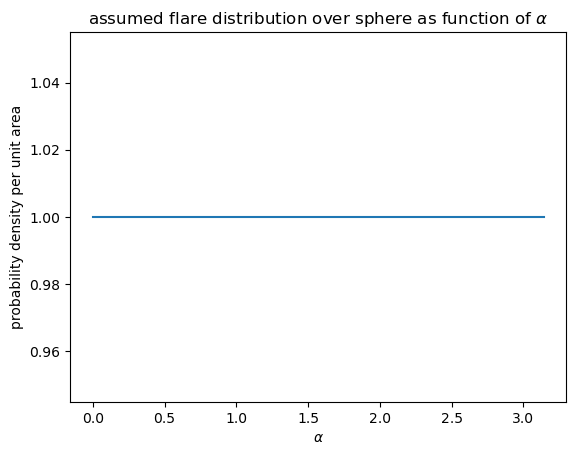

In [16]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return alpha * 0 + 1 /N

N = quad(lambda a :  rho(a) * np.sin(a), 0, np.pi/2)[0]
print(N)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [17]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

    
def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()


0.0 (12.566370614359176, 1.395147399203453e-13)
0.39269908169872414 (12.566370614359176, 1.395147399203453e-13)
0.7853981633974483 (12.566370614359176, 1.395147399203453e-13)
1.1780972450961724 (12.566370614359176, 1.395147399203453e-13)


1.5707963267948966 (12.566370614359176, 1.395147399203453e-13)


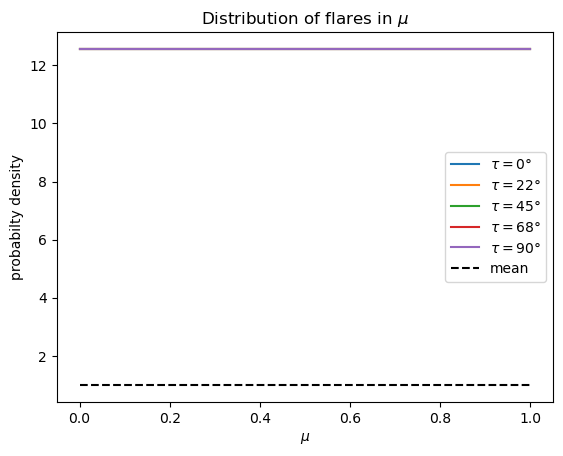

File 'calculations/uniformdist_rotation.npy' found.


In [18]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dops = np.linspace(0,1.8, 40)
dens = get_or_create_data("uniformdist")


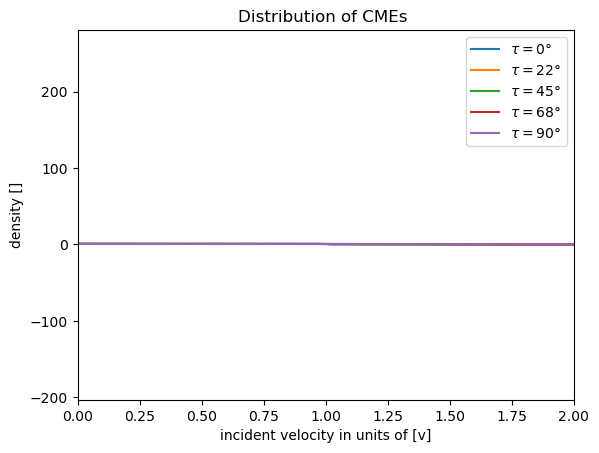

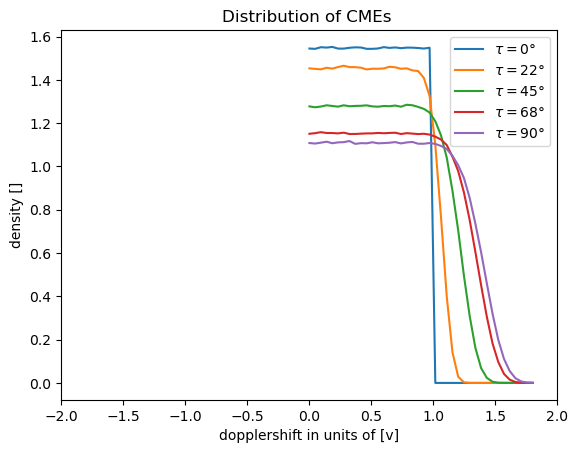

In [19]:
# def speed2beta(v):
#     return np.arccos(v / 600 )

# def beta2speed(beta):
#     return  np.cos(beta) * 600

# from scipy.interpolate import make_interp_spline


def plotting_2(dens, taus):
    for i,d in enumerate(dens):
        # smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(dops, d, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    # plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    # plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    # ax = plt.gca()
    # secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    # secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel("dopplershift in units of [v]")
    plt.ylabel(r"density []")
    plt.xlim(-2, 2)
    # plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)
plotting_2(dens, Taus)

